In [1]:
import json
import pathlib
import pandas as pd

# Override to a specific path to inspect a particular run; leave None to auto-pick latest.
EVENTS_FILE = None

if EVENTS_FILE is None:
    sim_data = pathlib.Path('..') / 'data'
    candidates = list(sim_data.glob('events-*.jsonl')) + list((sim_data / 'runs').glob('events-*.jsonl'))
    if not candidates:
        raise FileNotFoundError(f'no events-*.jsonl under {sim_data} or {sim_data / "runs"}')
    EVENTS_FILE = max(candidates, key=lambda p: p.stat().st_mtime)
else:
    EVENTS_FILE = pathlib.Path(EVENTS_FILE)

print(f'loading {EVENTS_FILE}')

records = [json.loads(line) for line in EVENTS_FILE.read_text().splitlines() if line.strip()]
df = pd.json_normalize(records).sort_values('ts').reset_index(drop=True)
print(f"{len(df)} events, {df['node'].nunique()} nodes, span {df['ts'].max() - df['ts'].min():.0f}s")
df.head()

loading ../data/events-20260508_104707.jsonl
84 events, 2 nodes, span 203s


,ts,src_ip,timestamp,node,event,data.parent,data.btc_address,data.starting_balance_sat,data.version,data.ts,...,data.peer_count,data.spawn_in_progress,data.failsafe_in_progress,data.git_commit_hash,data.public_ip,data.live_peer_count,data.action,data.success,data.spawn_id,data.child_share_sat
0,1.778227e+09,10.215.172.205,2026-05-08T07:49:18.555104+00:00,genesis,birth,genesis,bcrt1qgkltdlykfrq22vkvkrc6l8ysg2qgn52exhdfs5,0.0,unknown,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.778227e+09,10.215.172.205,2026-05-08T07:49:18.558652+00:00,genesis,state_snapshot,NaN,bcrt1qgkltdlykfrq22vkvkrc6l8ysg2qgn52exhdfs5,NaN,NaN,1.778227e+09,...,0.0,False,False,unknown,10.215.172.205,NaN,NaN,NaN,NaN,NaN
2,1.778227e+09,10.215.172.205,2026-05-08T07:49:23.562527+00:00,genesis,state_snapshot,NaN,bcrt1quvlw0cxxc8m2ys5pm3vnw4xle5l2p0n4qjhxxq,NaN,NaN,1.778227e+09,...,0.0,False,False,unknown,10.215.172.205,NaN,NaN,NaN,NaN,NaN
3,1.778227e+09,10.215.172.205,2026-05-08T07:49:28.566244+00:00,genesis,state_snapshot,NaN,bcrt1quvlw0cxxc8m2ys5pm3vnw4xle5l2p0n4qjhxxq,NaN,NaN,1.778227e+09,...,0.0,False,False,unknown,10.215.172.205,NaN,NaN,NaN,NaN,NaN
4,1.778227e+09,10.215.172.205,2026-05-08T07:49:33.570773+00:00,genesis,state_snapshot,NaN,bcrt1quvlw0cxxc8m2ys5pm3vnw4xle5l2p0n4qjhxxq,NaN,NaN,1.778227e+09,...,0.0,False,False,unknown,10.215.172.205,NaN,NaN,NaN,NaN,NaN


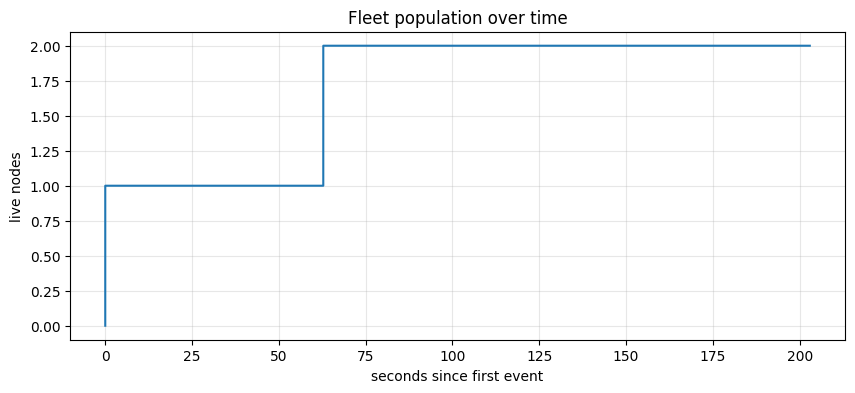

In [2]:
import matplotlib.pyplot as plt

# 5x sim-mode HEARTBEAT_INTERVAL (run_simulation.py overrides it to 5s).
DEATH_TIMEOUT = 25

snaps = df[df['event'] == 'state_snapshot'].copy()
ts_axis = sorted(df['ts'].unique())
t0 = df['ts'].min()
populations = [
    snaps[(snaps['ts'] <= t) & (snaps['ts'] > t - DEATH_TIMEOUT)]['node'].nunique()
    for t in ts_axis
]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot([t - t0 for t in ts_axis], populations)
ax.set_xlabel('seconds since first event')
ax.set_ylabel('live nodes')
ax.set_title('Fleet population over time')
ax.grid(True, alpha=0.3)
plt.show()

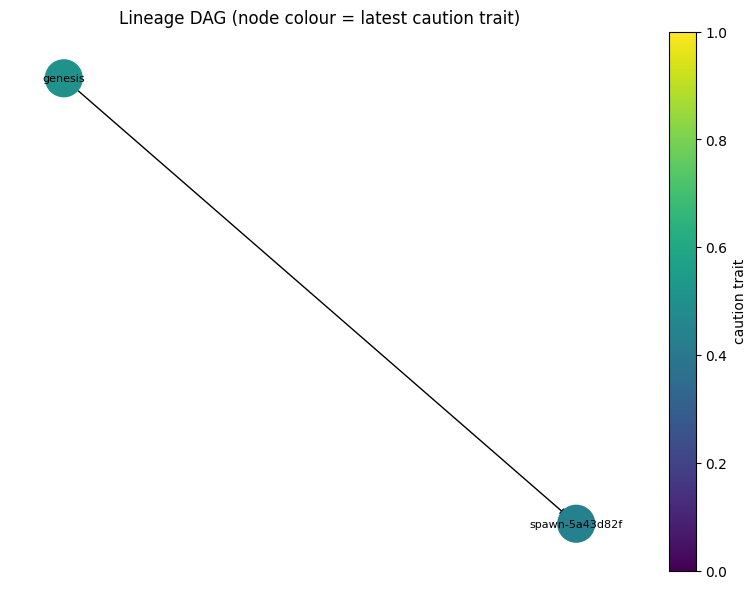

In [3]:
import networkx as nx

births = df[df['event'] == 'birth']
caution_by_node = (
    snaps.sort_values('ts')
         .groupby('node')['data.caution_trait']
         .last()
         .to_dict()
)

G = nx.DiGraph()
for _, row in births.iterrows():
    parent, child = row.get('data.parent'), row['node']
    G.add_node(child)
    if parent and parent != child:
        G.add_edge(parent, child)

pos = nx.spring_layout(G, seed=42) if len(G) > 1 else {n: (0, 0) for n in G.nodes}
caution_vals = [caution_by_node.get(n, 0.5) for n in G.nodes]

fig, ax = plt.subplots(figsize=(10, 7))
nx.draw_networkx_nodes(G, pos, node_color=caution_vals, cmap='viridis', vmin=0, vmax=1, node_size=700, ax=ax)
nx.draw_networkx_edges(G, pos, arrows=True, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(0, 1))
sm.set_array([])
fig.colorbar(sm, ax=ax, label='caution trait')
ax.set_title('Lineage DAG (node colour = latest caution trait)')
ax.axis('off')
plt.show()

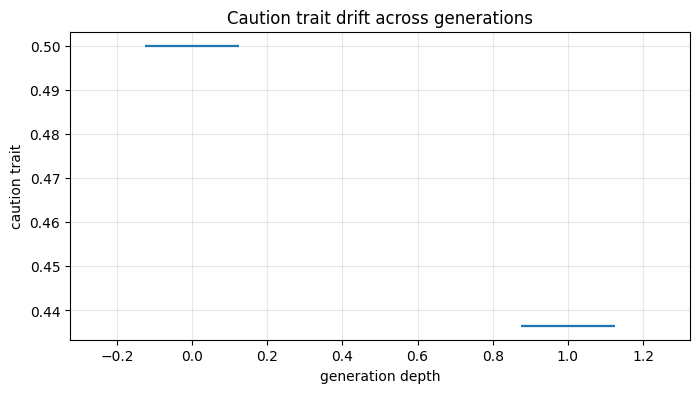

In [4]:
def generation_depth(node):
    if node == 'genesis':
        return 0
    try:
        return nx.shortest_path_length(G, 'genesis', node)
    except (nx.NodeNotFound, nx.NetworkXNoPath):
        return -1

depth_rows = [
    {'depth': generation_depth(node), 'caution': caution}
    for node, caution in caution_by_node.items()
]
drift = pd.DataFrame([r for r in depth_rows if r['depth'] >= 0])

if drift.empty:
    print('no caution data with computable depth')
else:
    depths = sorted(drift['depth'].unique())
    data_per_depth = [drift[drift['depth'] == d]['caution'].values for d in depths]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.violinplot(data_per_depth, positions=depths, showmeans=True)
    ax.set_xlabel('generation depth')
    ax.set_ylabel('caution trait')
    ax.set_title('Caution trait drift across generations')
    ax.grid(True, alpha=0.3)
    plt.show()

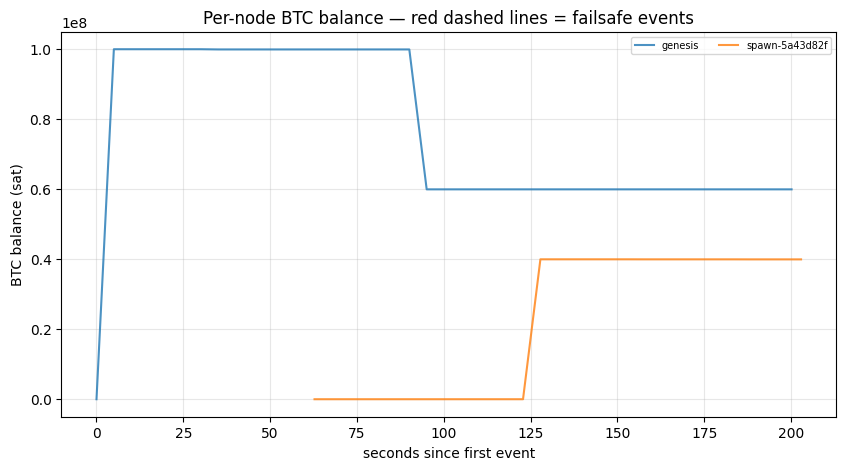

Inheritance transfers (parent → child):
  (none)


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
for node, sub in snaps.groupby('node'):
    ax.plot(sub['ts'] - t0, sub['data.btc_balance_sat'], label=node, alpha=0.8)

failsafes = df[df['event'].astype(str).str.startswith('failsafe')]
for t in failsafes['ts']:
    ax.axvline(t - t0, color='red', linestyle='--', alpha=0.5)

ax.set_xlabel('seconds since first event')
ax.set_ylabel('BTC balance (sat)')
ax.set_title('Per-node BTC balance — red dashed lines = failsafe events')
if snaps['node'].nunique() <= 30:
    ax.legend(fontsize=7, loc='upper right', ncol=2)
ax.grid(True, alpha=0.3)
plt.show()

if 'data.starting_balance_sat' in births.columns:
    transfers = births[births['data.starting_balance_sat'].fillna(0) > 0][
        ['data.parent', 'node', 'data.starting_balance_sat']
    ].rename(columns={'data.parent': 'parent', 'node': 'child', 'data.starting_balance_sat': 'sat'})
    print('Inheritance transfers (parent → child):')
    print(transfers.to_string(index=False) if not transfers.empty else '  (none)')